Comenzaremos con la preparación del dataset previa a la implementación del modelo. El primer paso será la importación de las librerías necesarias y el dataset objetivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = 'Lorca_original.csv' #Lorca_original.csv para el de Lorca, Murcia
                             #CTC_original.csv para el de Santander, Cantabria
data = pd.read_csv(dataset, sep=";")

data.head() #Mostramos primeras filas

,datetime,temperature,windSpeed,solarRad,humedad,rain,Power_gen,pressure_sensor,pressure
0,01/02/2024 18:25,12.05560,16.09340,7,70,0.0,0.0,446.901518,29.206
1,01/02/2024 19:35,10.33330,1.60934,0,77,0.0,0.0,445.225016,29.218
2,01/02/2024 20:45,9.50000,1.60934,0,76,0.0,0.0,448.802490,29.209
3,01/02/2024 21:55,9.33333,0.00000,0,77,0.0,0.0,454.271430,29.202
4,01/02/2024 23:05,8.77778,1.60934,0,80,0.0,0.0,451.221255,29.204


- datetime: Fecha
- Power_gen: Potencia generada en kilovatios
- temperature: Temperatura en grados celsius
- windSpeed: Velocidad del viento en kilómetros/hora
- solarRad: Irradiancia solar en vatios/metro cuadrado
- humedad: Porcentaje de humedad
- rain: Lluvia en milímetros
- pressure: Presión en hectopascales

Visualizamos información referente al dataset.

In [2]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47151 entries, 0 to 47150
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         47151 non-null  object 
 1   temperature      47151 non-null  float64
 2   windSpeed        47151 non-null  float64
 3   solarRad         47151 non-null  int64  
 4   humedad          47151 non-null  int64  
 5   rain             47151 non-null  float64
 6   Power_gen        46897 non-null  float64
 7   pressure_sensor  47151 non-null  float64
 8   pressure         47151 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 3.2+ MB


Como necesitaremos las columnas en valores numéricos, debemos pasar las de tipo objeto a tipo float antes de continuar.

In [3]:
cols = [c for c in data.columns if c != "datetime"]

#Antes de pasar a float, limpiamos los datos (eliminando las unidades y dejando solo el valor numérico)
for c in cols:
    s = data[c].astype(str)
    s = s.str.replace(r"[^0-9\.,-]", "", regex=True)
    s = s.str.replace(",", ".", regex=False)
    data[c] = pd.to_numeric(s, errors="coerce")

data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47151 entries, 0 to 47150
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         47151 non-null  object 
 1   temperature      47151 non-null  float64
 2   windSpeed        47151 non-null  float64
 3   solarRad         47151 non-null  int64  
 4   humedad          47151 non-null  int64  
 5   rain             47151 non-null  float64
 6   Power_gen        46897 non-null  float64
 7   pressure_sensor  47151 non-null  float64
 8   pressure         47151 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 3.2+ MB


Ahora que tenemos los datos limpios y en formato numérico, mostramos la descripción estadística para observar valores como la media, máximo, ...

In [4]:
data.describe()

,temperature,windSpeed,solarRad,humedad,rain,Power_gen,pressure_sensor,pressure
count,47151.000000,47151.000000,47151.000000,47151.000000,47151.000000,46897.000000,47151.000000,47151.000000
mean,22.123899,9.341301,228.371975,55.504146,0.049106,4.518137,274.115060,28.718992
std,17.448625,8.523832,416.852385,17.596303,0.404363,6.440821,276.736770,0.301967
min,4.555560,0.000000,0.000000,12.000000,0.000000,0.000000,-732.172846,0.000000
25%,17.833300,3.218690,0.000000,42.000000,0.000000,0.000000,247.120408,28.658000
50%,22.277800,8.046720,46.000000,54.000000,0.000000,0.000000,331.265815,28.728000
75%,25.888900,14.484100,422.000000,69.000000,0.000000,8.749000,384.834917,28.799000
max,1802.610000,410.383000,32767.000000,255.000000,10.599999,28.982000,728.793044,29.298000


Observamos que hay valores claramente erróneos que alteran los resultados (temperature=1803, windSpeed=410,...). Posteriormente los trataremos.

Histograma:

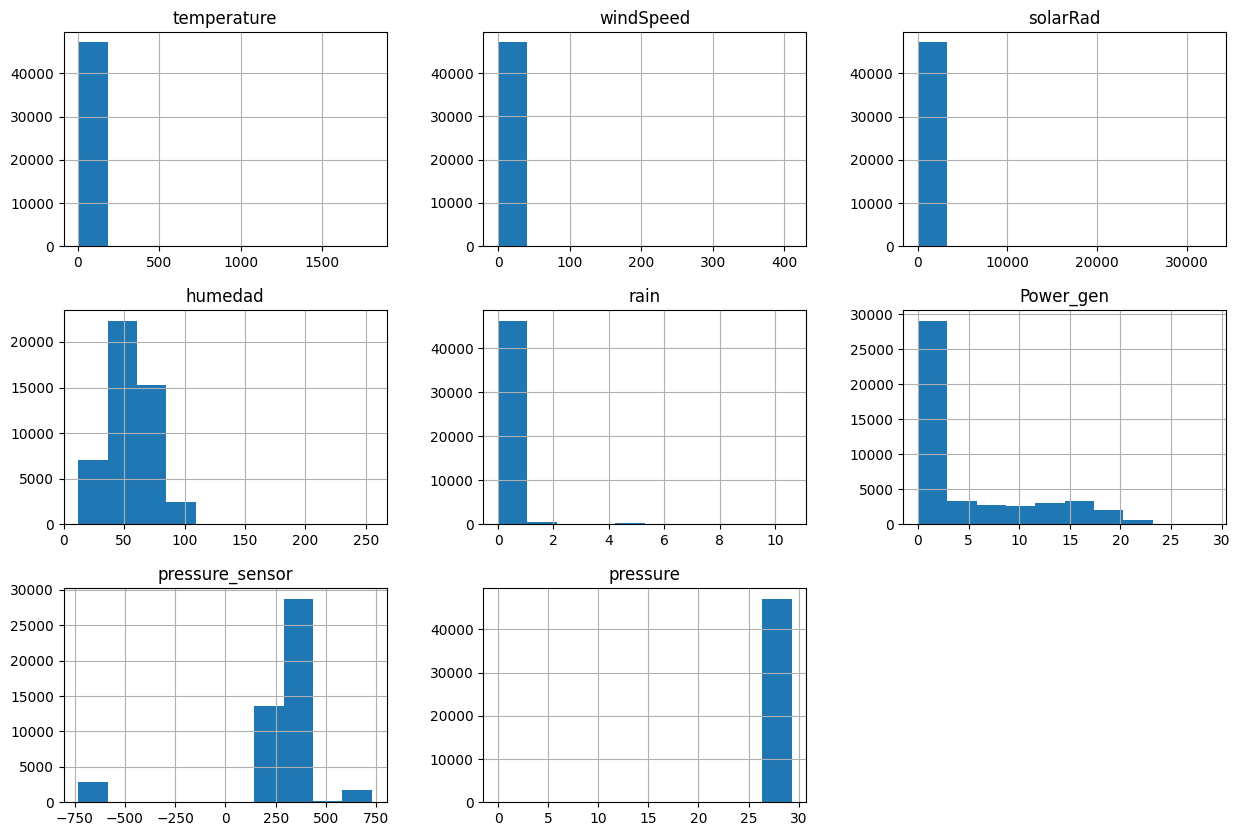

In [5]:
histograma = data.hist(figsize=(15, 10))

Podemos observar que los valores de todas las variables se concentran mayoritariamente en una parte del histograma, con valores extraordinarios muy alejados de esta. Power_gen y pressure son la excepción, ya que si presentan histogramas razonables.

Con violinplots se observa claramente:

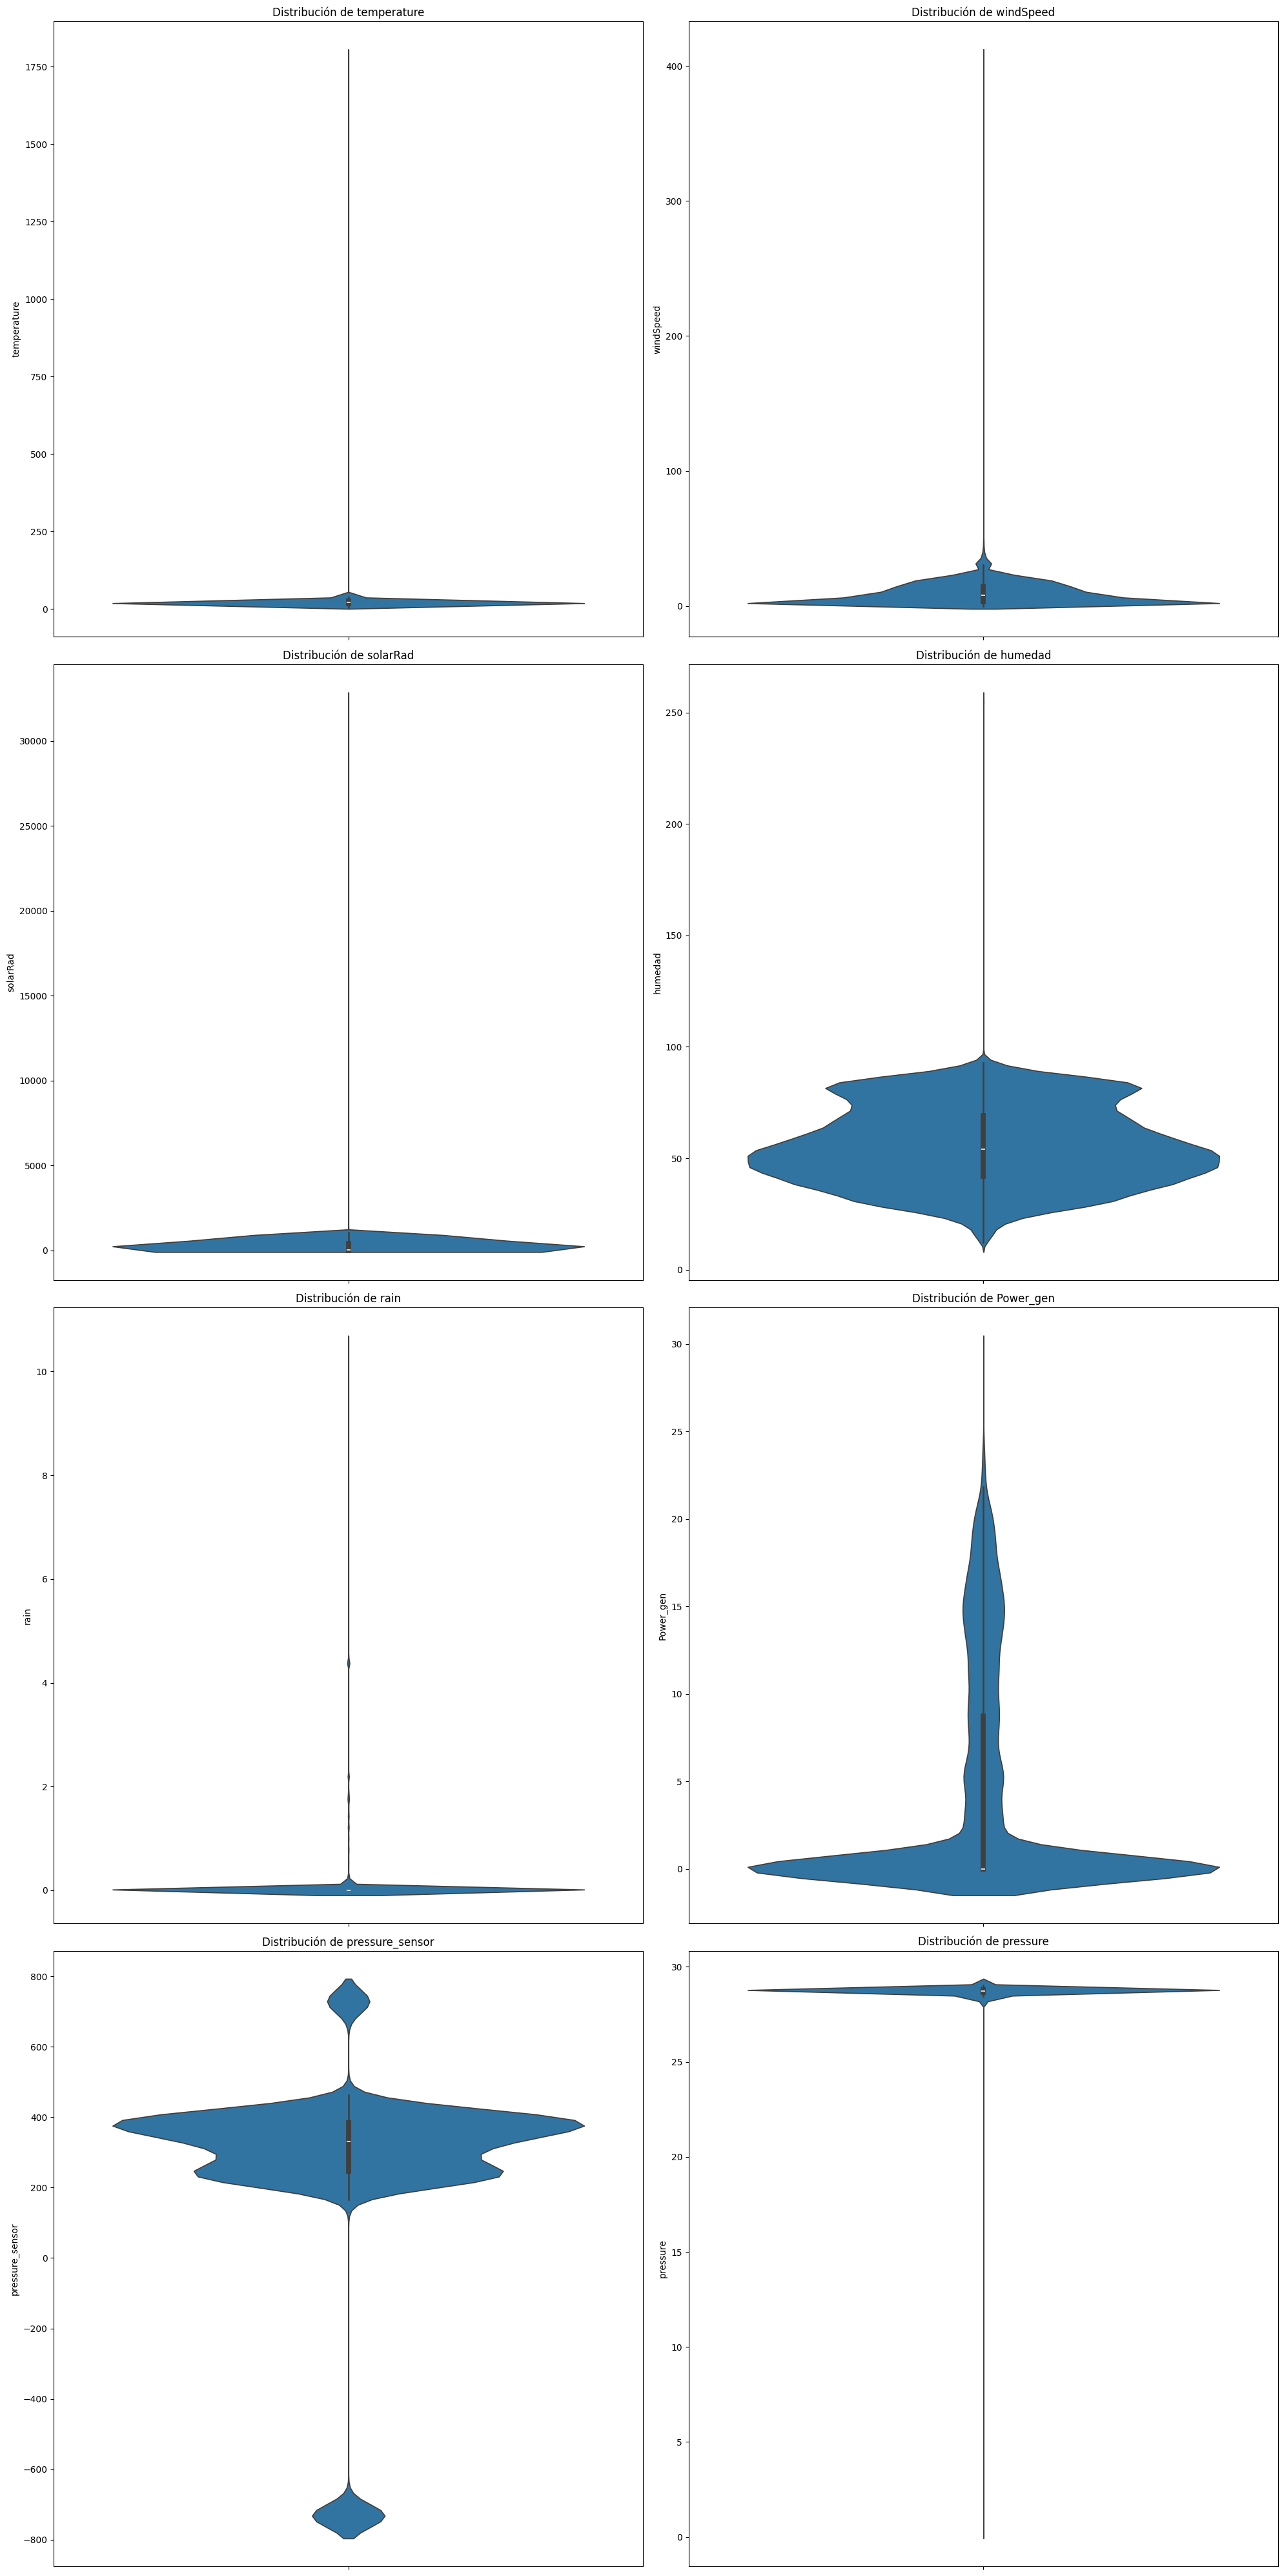

In [6]:
#Creamos una lista con las variables numéricas (todas menos datetime)
numeric_cols = data.drop(columns=['datetime'])

#Numero de filas y columnas para los subplots
filas, columnas =4,2

#Creamos figura y ejes para los subplots
fig,axes = plt.subplots(filas, columnas, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    sns.violinplot(y=numeric_cols[col], ax=axes[i])

for ax, col in zip(axes, numeric_cols):
    ax.set_title(f'Distribución de {col}')


plt.tight_layout()
plt.show()

Como los outliers alteran enormemente el resultado del modelo, hemos de eliminarlos del dataset.

Para calcular los outliers, hemos de calcular primero el IQR de cada variable. Esto es la diferencia entre el percentil 75 y el percentil 25, de forma que el valor resultante representa el rango en el que se encuentra el 50% central de los datos. Normalmente, se consideran outliers los valores por debajo de (percentil 25 - 1.5 * IQR) o por encima de (percentil 75 + 1.5 * IQR).

In [7]:
outlier_cols = data.select_dtypes(include=[np.number]).columns.drop('Power_gen')

P25 = data[outlier_cols].quantile(0.25) #Percentil 25
P75 = data[outlier_cols].quantile(0.75) #Percentil 75
IQR = P75 - P25 #Interquartile Range


#Identificar outliers
outliers = ((data[outlier_cols] < (P25 - 1.5 * IQR)) | (data[outlier_cols] > (P75 + 1.5 * IQR)))
print('Outliers detectados:\n')
print(outliers.sum())

Outliers detectados:

temperature          86
windSpeed           504
solarRad             26
humedad               4
rain               1226
pressure_sensor    4619
pressure           3526
dtype: int64


Con los outliers detectados, procedemos a eliminarlos del dataset.

In [8]:
data = data.loc[~outliers.any(axis=1)].reset_index(drop=True)

Volvemos a mostrar los histogramas y violinplots para ver el resultado

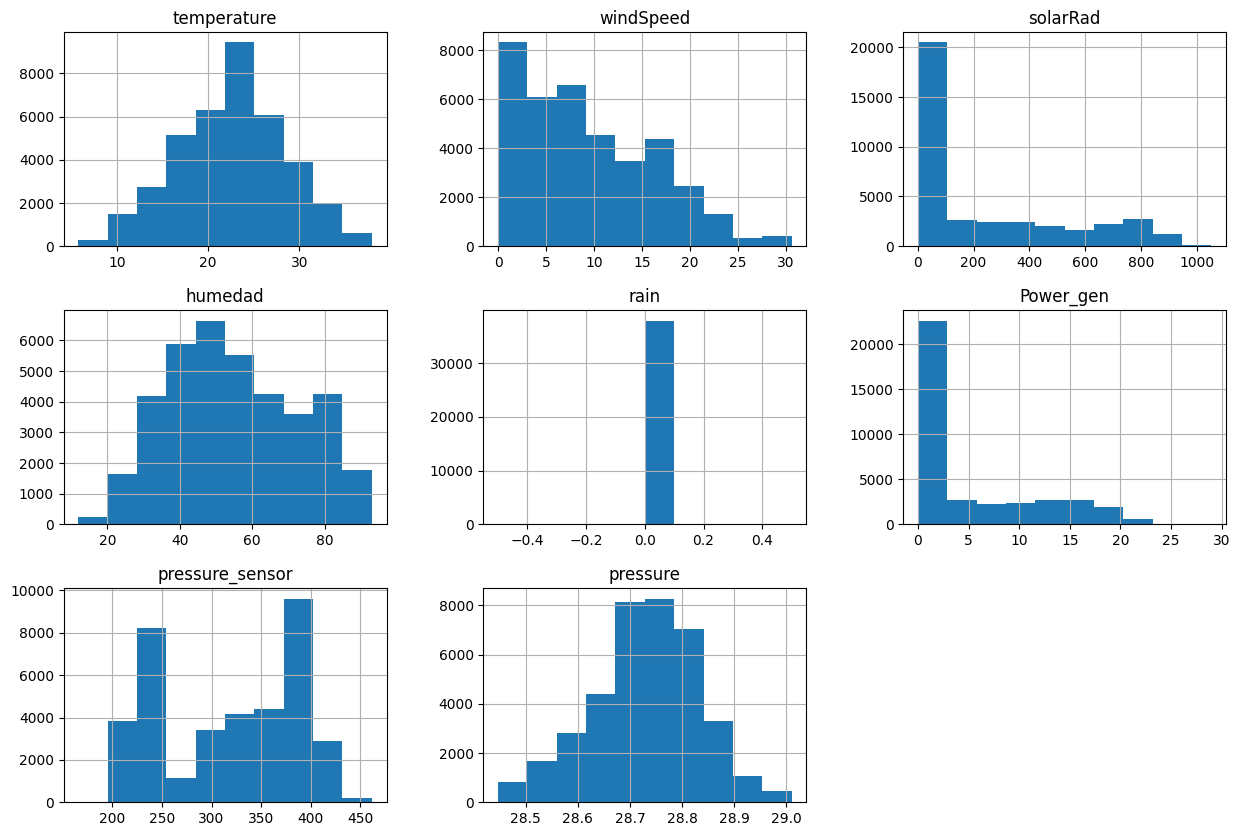

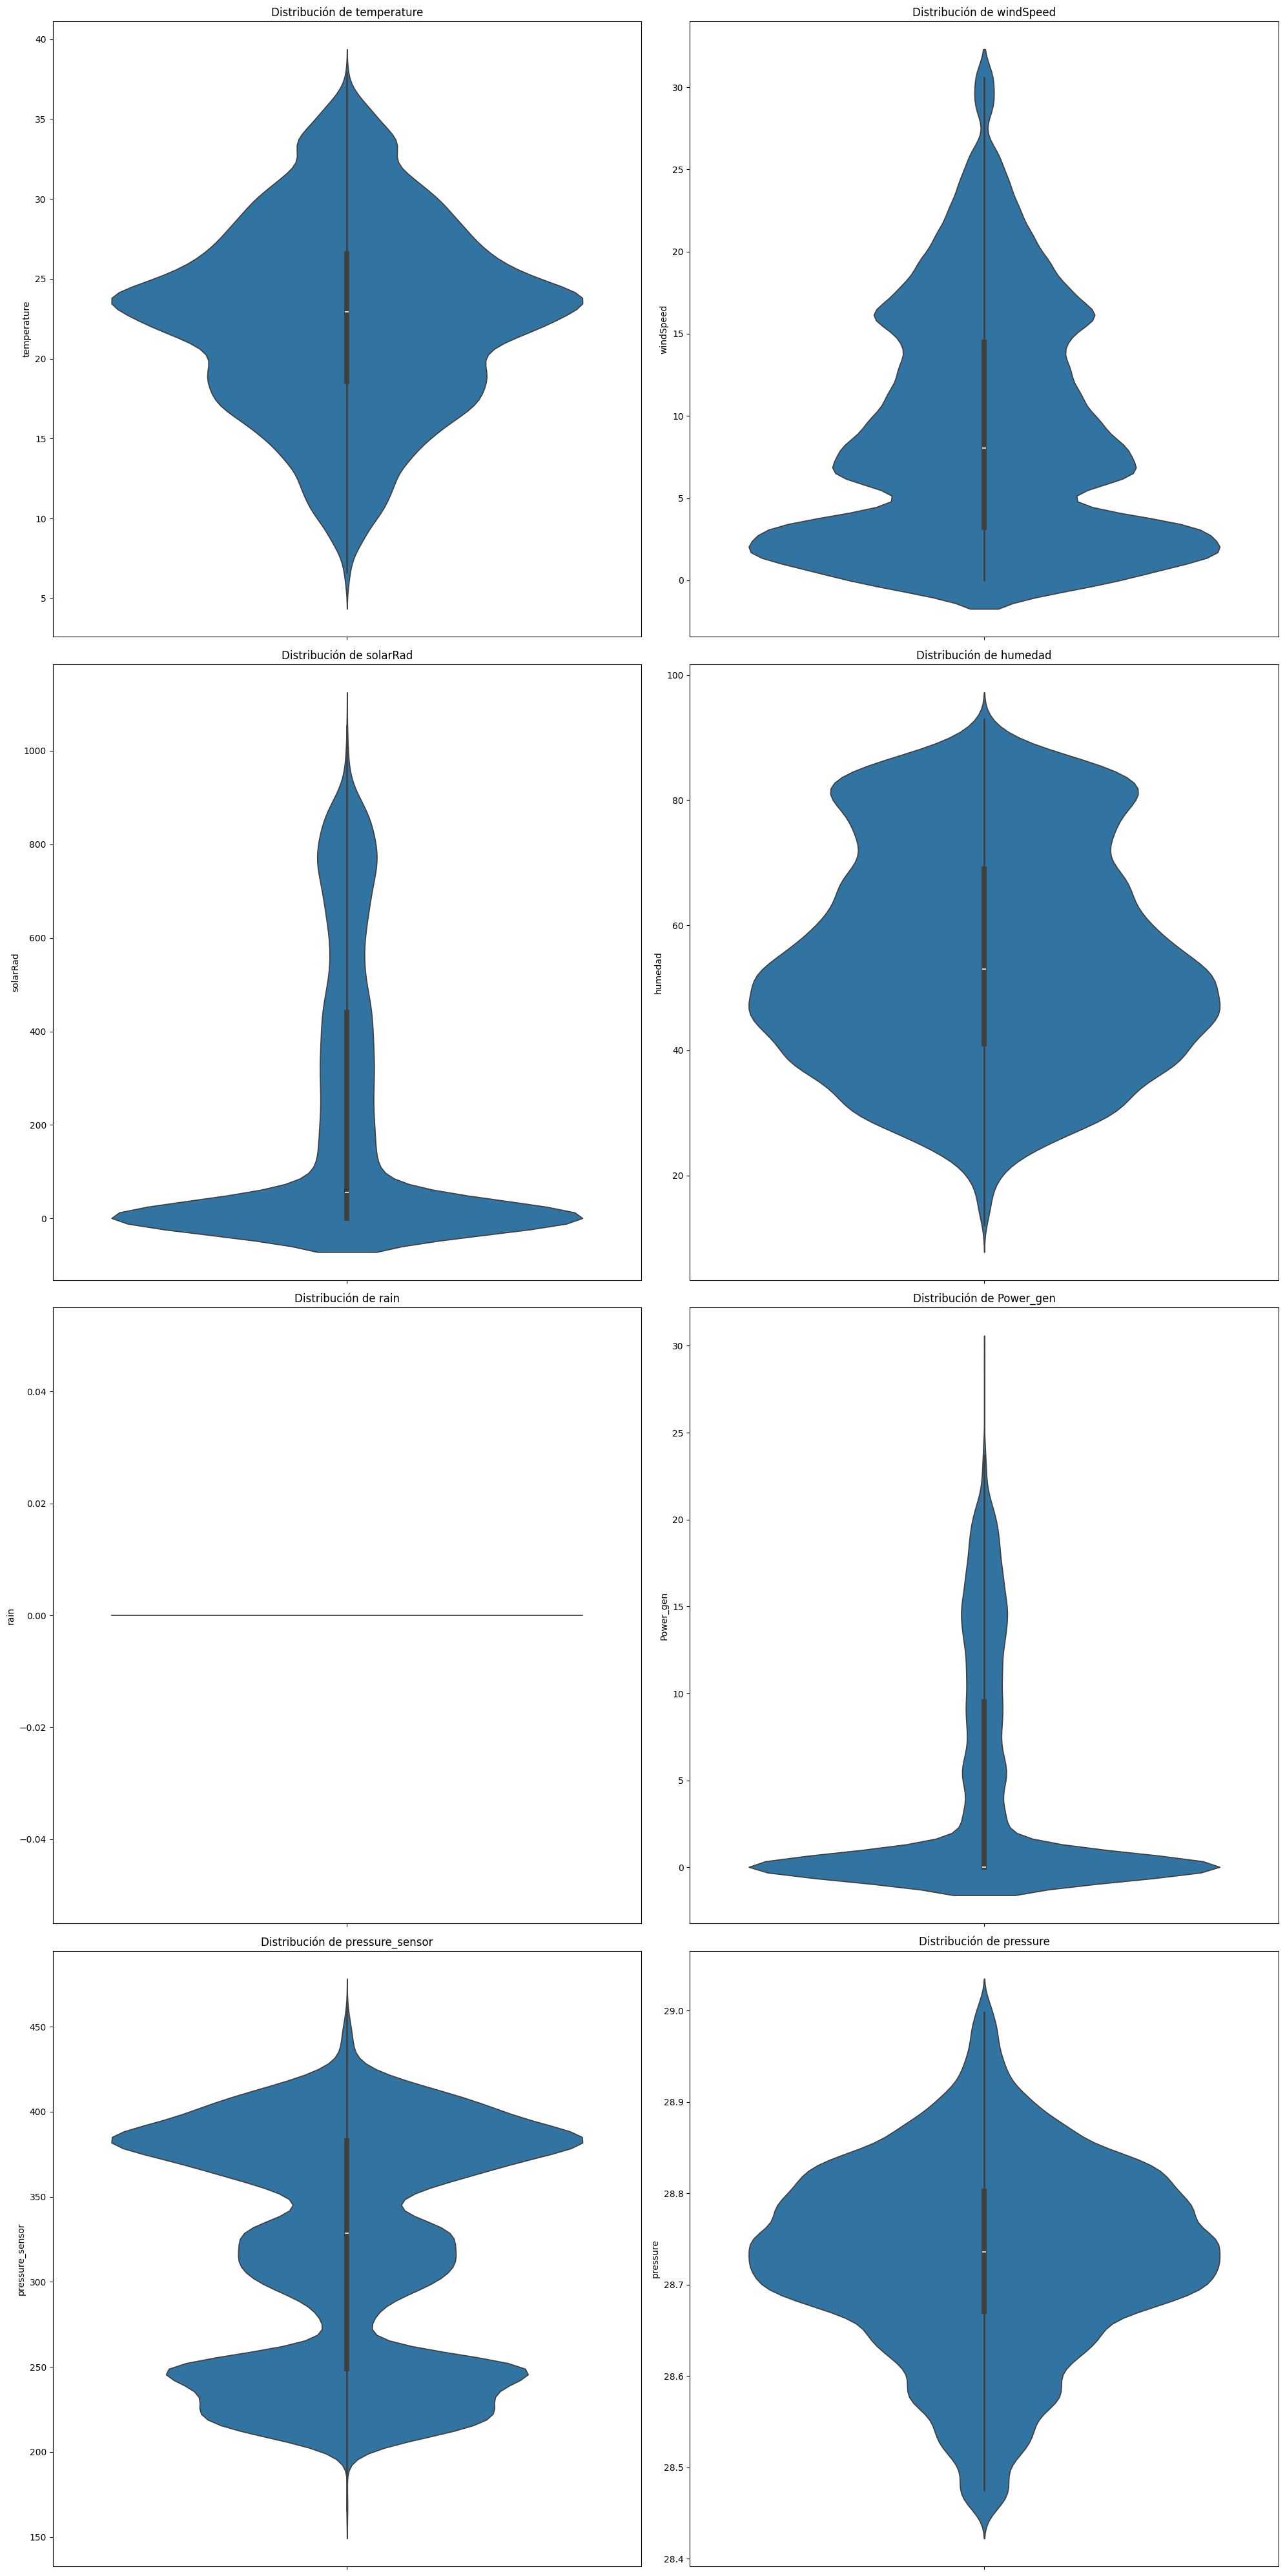

In [9]:
histograma = data.hist(figsize=(15, 10))

#Creamos una lista con las variables numéricas (todas menos datetime)
numeric_cols = data.drop(columns=['datetime'])

#Numero de filas y columnas para los subplots
filas, columnas =4,2

#Creamos figura y ejes para los subplots
fig,axes = plt.subplots(filas, columnas, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    sns.violinplot(y=numeric_cols[col], ax=axes[i])

for ax, col in zip(axes, numeric_cols):
    ax.set_title(f'Distribución de {col}')


plt.tight_layout()
plt.show()

Consultamos la nueva información y descripción analítica.

In [10]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37956 entries, 0 to 37955
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         37956 non-null  object 
 1   temperature      37956 non-null  float64
 2   windSpeed        37956 non-null  float64
 3   solarRad         37956 non-null  int64  
 4   humedad          37956 non-null  int64  
 5   rain             37956 non-null  float64
 6   Power_gen        37742 non-null  float64
 7   pressure_sensor  37956 non-null  float64
 8   pressure         37956 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.6+ MB


In [11]:
data.describe()

,temperature,windSpeed,solarRad,humedad,rain,Power_gen,pressure_sensor,pressure
count,37956.000000,37956.000000,37956.000000,37956.000000,37956.0,37742.000000,37956.000000,37956.000000
mean,22.635885,9.143911,234.757719,54.913189,0.0,4.818164,319.204056,28.730713
std,5.891414,7.165177,294.758738,17.490909,0.0,6.590055,67.955843,0.102434
min,5.777780,0.000000,0.000000,12.000000,0.0,0.000000,165.630128,28.447000
25%,18.555600,3.218690,0.000000,41.000000,0.0,0.000000,248.893325,28.671000
50%,22.944400,8.046720,56.000000,53.000000,0.0,0.000000,328.621363,28.736000
75%,26.555600,14.484100,441.000000,69.000000,0.0,9.506000,382.983982,28.802000
max,37.944400,30.577500,1053.000000,93.000000,0.0,28.982000,461.693549,29.010000


Observamos que los valores imposibles se han eliminado, dejando como resultado los valores reales.

Eliminamos filas con NaN

In [12]:
data = data.dropna()

Información y descripción del dataset final

In [13]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 37742 entries, 0 to 37955
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         37742 non-null  object 
 1   temperature      37742 non-null  float64
 2   windSpeed        37742 non-null  float64
 3   solarRad         37742 non-null  int64  
 4   humedad          37742 non-null  int64  
 5   rain             37742 non-null  float64
 6   Power_gen        37742 non-null  float64
 7   pressure_sensor  37742 non-null  float64
 8   pressure         37742 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.9+ MB


In [14]:
data.describe()

,temperature,windSpeed,solarRad,humedad,rain,Power_gen,pressure_sensor,pressure
count,37742.000000,37742.000000,37742.000000,37742.000000,37742.0,37742.000000,37742.000000,37742.000000
mean,22.624757,9.141817,233.986461,54.936808,0.0,4.818164,319.064670,28.730879
std,5.894591,7.164034,294.542128,17.488039,0.0,6.590055,68.009493,0.102527
min,5.777780,0.000000,0.000000,12.000000,0.0,0.000000,165.630128,28.447000
25%,18.500000,3.218690,0.000000,41.000000,0.0,0.000000,248.819056,28.671000
50%,22.944400,8.046720,54.000000,53.000000,0.0,0.000000,328.508944,28.737000
75%,26.541700,14.484100,441.000000,69.000000,0.0,9.506000,382.971147,28.802000
max,37.944400,30.577500,1053.000000,93.000000,0.0,28.982000,461.693549,29.010000


Para ver el grado de correlación entre las variables, usaremos un MinMaxScaler y un heatmap.

In [19]:
'''from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = data.copy()
data_scaled[numeric_cols.columns] = scaler.fit_transform(data_scaled[numeric_cols.columns])
data_scaled.drop(columns=["datetime"], inplace=True) #Eliminamos las columnas no numéricas, datetime en este caso'''

'from sklearn.preprocessing import MinMaxScaler\n\nscaler = MinMaxScaler()\ndata_scaled = data.copy()\ndata_scaled[numeric_cols.columns] = scaler.fit_transform(data_scaled[numeric_cols.columns])\ndata_scaled.drop(columns=["datetime"], inplace=True) #Eliminamos las columnas no numéricas, datetime en este caso'

In [20]:
'''corr_df = data_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()'''

"corr_df = data_scaled.corr(method ='spearman')\n\nplt.figure(figsize=(10, 10))\nsns.heatmap(corr_df, annot=True, cmap='coolwarm')\n\nplt.show()"

Guardamos en un CSV nuevo

In [15]:
if dataset == 'Lorca_original.csv':
    data = data.loc[data['Power_gen'].shift() != data['Power_gen']]#eliminamos filas con valores repetidos en power_gen de forma local,
                                                                         #ya que la medicion de power_gen no es sincrona con las demas variables
    data.to_csv("Lorca_processed.csv", sep=";", index=False)
elif dataset == 'CTC_original.csv':
    data.to_csv("CTC_processed.csv", sep=";", index=False)